In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import drjit as dr
import mitsuba as mi

import sionna.rt
import os
   
no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, ITURadioMaterial, SceneObject

In [2]:
scene = load_scene(sionna.rt.scene.simple_street_canyon,
                   merge_shapes=False) # Disable merging of objects

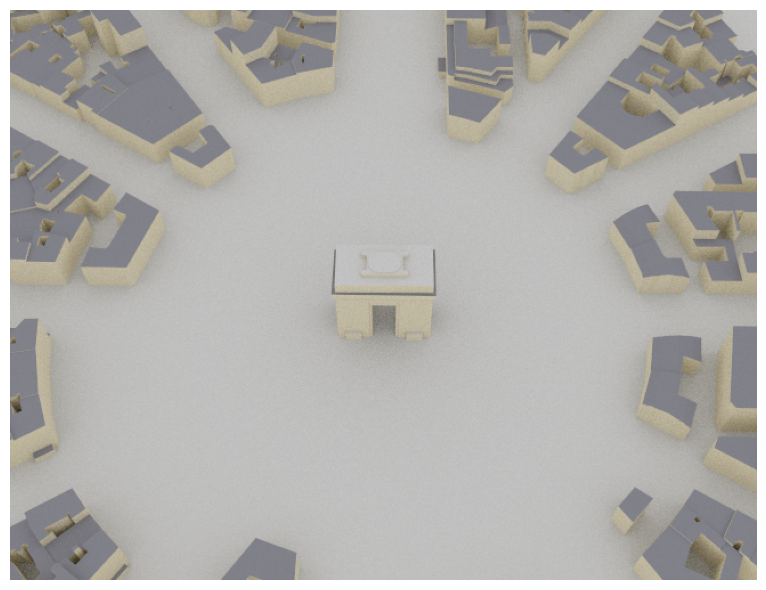

In [3]:
scene = load_scene(sionna.rt.scene.etoile) # Objects are merged by default

cam = Camera(position=[-360,145,400], look_at=[-115,33,1.5])
if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

In [4]:
# Number of cars to add
num_cars = 2

# Radio material constituing the cars
# We use ITU metal, and use red color for visualization to
# make the cars easily discernible
car_material = ITURadioMaterial("car-material",
                                "metal",
                                thickness=0.0001,
                                color=(0, 0, 1))

# Instantiate `num_cars` cars sharing the same mesh and material
car_path = "/home/icon-group/Documents/Josh/sionna/Tellus/sionna_test/jetbot_real/jet.obj"
cars = [SceneObject(fname=car_path, # Simple mesh of a car
                    name=f"car-{i}",
                    radio_material=car_material)
        for i in range(num_cars)]

# Add the list of newly instantiated objects to the scene
scene.edit(add=cars)

# if no_preview:
#     scene.render(camera=cam);
# else:
scene.preview();

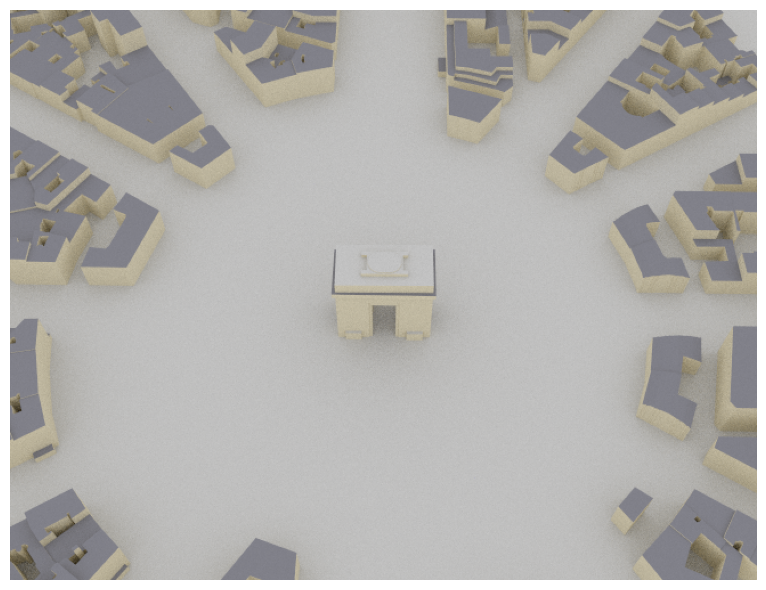

In [5]:
# Positions
# Car are positioned in a circle around the central monument
# Center of the circle
c = mi.Point3f(-127, 37, 1.5)
# Radius of the circle
r = 100
# Angles at which cars are positioned
thetas = dr.linspace(mi.Float, 0., dr.two_pi, num_cars, endpoint=False)
# Cars positions
cars_positions = c + mi.Point3f(dr.cos(thetas), dr.sin(thetas), 0.)*r

# Orientations
# Compute points the car "look-at" to set their orientation
d = dr.normalize(cars_positions - c)
# Tangent vector to the circle at the car position
look_at_dirs = mi.Vector3f(d.y, -d.x, 0.)
look_at_points = cars_positions + look_at_dirs

# Set the cars positions and orientations
for i in range(num_cars):
    
    cars[i].position = mi.Point3f(cars_positions.x[i], cars_positions.y[i], cars_positions.z[i])
    cars[i].look_at(mi.Point3f(look_at_points.x[i], look_at_points.y[i], look_at_points.z[i]))

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

In [ ]:
#!/usr/bin/env python3

import rospy
from geometry_msgs.msg import Point
from nav_msgs.msg import Odometry
import sionna.rt
import os
import tf
import mitsuba as mi

import matplotlib.pyplot as plt
import numpy as np
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial, SceneObject

robot1_pos = Point()
robot2_pos = Point()

robot1_orien = Point()
robot2_orien = Point()

no_preview = False


def position_callback1(msg):
    global robot1_pos
    robot1_pos.x = round(msg.x,2)
    robot1_pos.y = round(msg.y,2)
    robot1_pos.z = round(msg.z,2)


def position_callback2(msg):
    global robot2_pos
    robot2_pos.x = round(msg.x,2)
    robot2_pos.y = round(msg.y,2)
    robot2_pos.z = round(msg.z,2)


def odom_callback1(msg):
    global robot1_pos, robot1_orien
    position = msg.pose.pose.position
    robot1_pos.x = position.x
    robot1_pos.y = position.y
    robot1_pos.z = position.z

    q = msg.pose.pose.orientation
    quaternion = (q.x, q.y, q.z, q.w)

    roll, pitch, yaw = tf.transformations.euler_from_quaternion(quaternion)

    robot1_orien.x = roll
    robot1_orien.y = pitch
    robot1_orien.z = yaw


def odom_callback2(msg):
    global robot2_pos, robot2_orien
    position = msg.pose.pose.position
    robot2_pos.x = position.x
    robot2_pos.y = position.y
    robot2_pos.z = position.z

    q = msg.pose.pose.orientation
    quaternion = (q.x, q.y, q.z, q.w)

    roll, pitch, yaw = tf.transformations.euler_from_quaternion(quaternion)

    robot2_orien.x = roll
    robot2_orien.y = pitch
    robot2_orien.z = yaw


def main():
    rospy.init_node("position_subscriber")

    # rospy.Subscriber("/jb_0/pos", Point, position_callback1)
    # rospy.Subscriber("/jb_1/pos", Point, position_callback2)

    rospy.Subscriber("/tb3_0/odom", Odometry, odom_callback1)
    rospy.Subscriber("/tb3_1/odom", Odometry, odom_callback2)

    rospy.loginfo("Subscribed to /robot_position")

    scene = load_scene("/home/icon-group/Documents/Josh/sionna/Tellus/sionna_test/with_materials/untitled.xml") 
    car_path = "/home/icon-group/Documents/Josh/sionna/Tellus/sionna_test/jetbot_real/jet.obj"

    if not no_preview:
            scene.preview();
    

    num_cars = 2
    car_material = ITURadioMaterial("car-material",
                                "metal",
                                thickness=0.0001,
                                color=(0, 0, 1))

    cars = [SceneObject(fname=car_path ,   #sionna.rt.scene.low_poly_car, # Simple mesh of a car
                    name=f"car-{i}",
                    radio_material=car_material)
        for i in range(num_cars)]

    scene.edit(add=cars)
    
    # cars[i].look_at(mi.Point3f(look_at_points.x[i], look_at_points.y[i], look_at_points.z[i]))

    
    
    while not rospy.is_shutdown():
        global robot1_pos,robot2_pos

        if not no_preview:
            my_cam = Camera(position=[20,20,30], look_at=[0,0,0])
            scene.render(camera=my_cam, resolution=[650, 500], num_samples=512);
            scene.render_to_file(camera=my_cam,
                         filename="scene.png",
                         resolution=[650,500]);

        cars[0].position = mi.Point3f(robot1_pos.x, robot1_pos.y, robot1_pos.z)
        cars[0].look_at(mi.Point3f(robot1_orien.x, robot1_orien.y, robot1_orien.z))

        cars[1].position = mi.Point3f(robot2_pos.x, robot2_pos.y, robot2_pos.z)
        cars[1].look_at(mi.Point3f(robot2_orien.x, robot2_orien.y, robot2_orien.z))

        


if __name__ == "__main__":
    try:
        main()
    except rospy.ROSInterruptException:
        pass